In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\smart_healthcare_dataset.csv")

In [4]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, explorative = True)
profile.to_file("Healthcare.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:04<00:00,  3.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
df.corr(numeric_only = True)

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
age,1.000000,0.015033,0.003859,-0.019787,0.008363,0.009419,0.006772,-0.008315,0.003683,-0.006973,-0.000280,0.776642,0.822413,0.746787,NaN
bmi,0.015033,1.000000,0.012170,-0.024889,0.017704,-0.007405,0.012313,-0.017389,-0.014068,-0.017836,-0.006292,0.133455,0.017799,0.014510,NaN
exercise_level,0.003859,0.012170,1.000000,-0.024399,-0.002719,0.003167,0.000769,-0.013183,-0.001935,-0.013551,0.000282,-0.010010,-0.009843,-0.013742,NaN
smoking,-0.019787,-0.024889,-0.024399,1.000000,-0.006843,-0.009737,0.029875,-0.020267,-0.006866,-0.004122,-0.021124,0.027161,-0.022884,0.000975,NaN
alcohol,0.008363,0.017704,-0.002719,-0.006843,1.000000,0.015768,0.012417,0.001870,-0.009289,0.021178,0.001615,0.007335,0.027317,0.012735,NaN
blood_pressure,0.009419,-0.007405,0.003167,-0.009737,0.015768,1.000000,0.026302,0.016913,0.016055,-0.014058,-0.019225,0.041059,0.010722,0.039958,NaN
cholesterol,0.006772,0.012313,0.000769,0.029875,0.012417,0.026302,1.000000,0.000178,-0.010661,-0.004047,0.013570,0.018736,0.002031,-0.000410,NaN
glucose,-0.008315,-0.017389,-0.013183,-0.020267,0.001870,0.016913,0.000178,1.000000,-0.005039,0.012915,-0.008870,-0.009114,0.028910,-0.016370,NaN
fatigue,0.003683,-0.014068,-0.001935,-0.006866,-0.009289,0.016055,-0.010661,-0.005039,1.000000,0.008561,0.005361,0.004118,0.009621,0.008895,NaN
chest_pain,-0.006973,-0.017836,-0.013551,-0.004122,0.021178,-0.014058,-0.004047,0.012915,0.008561,1.000000,-0.007559,0.038855,-0.000826,-0.012469,NaN


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

In [48]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'Female': np.int64(0), 'Male': np.int64(1)}


In [21]:
df['gender'].head()

0    1
1    0
2    0
3    0
4    0
Name: gender, dtype: int64

In [37]:
df['exercise_level'].head()

0    2
1    0
2    1
3    0
4    2
Name: exercise_level, dtype: int64

In [38]:
diabetes_rate_by_exercise = df.groupby('exercise_level')['diabetes'].mean()

diabetes_rate_by_exercise_sorted = diabetes_rate_by_exercise.sort_values(ascending=False)
print(diabetes_rate_by_exercise_sorted)

exercise_level
1    0.355993
0    0.351548
2    0.340095
Name: diabetes, dtype: float64


In [39]:
crosstab_result = pd.crosstab(df['exercise_level'], df['diabetes'], normalize = 'index')
print(crosstab_result)

diabetes               0         1
exercise_level                    
0               0.648452  0.351548
1               0.644007  0.355993
2               0.659905  0.340095


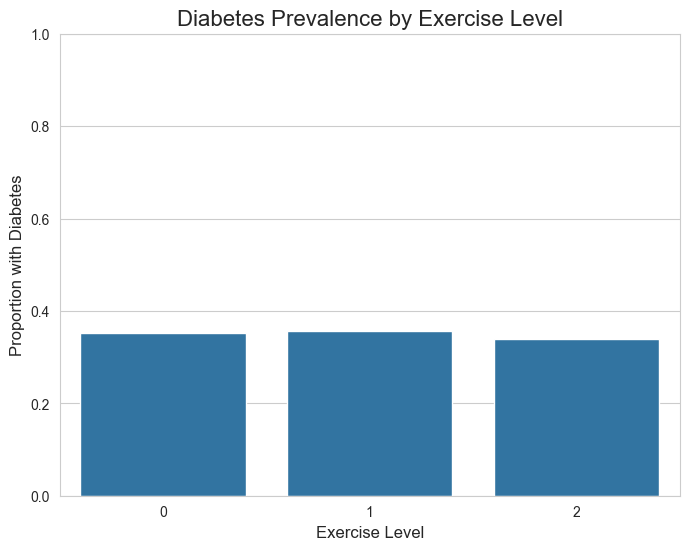

In [40]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(x=diabetes_rate_by_exercise.index, y=diabetes_rate_by_exercise.values)
plt.title('Diabetes Prevalence by Exercise Level', fontsize=16)
plt.xlabel('Exercise Level', fontsize=12)
plt.ylabel('Proportion with Diabetes', fontsize=12)
plt.ylim(0, 1)  
plt.show()

In [41]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['exercise_level'], df['diabetes'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.6090284165470619


<Axes: xlabel='exercise_level', ylabel='age'>

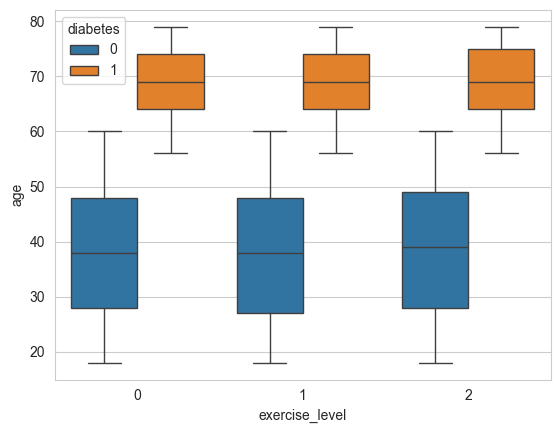

In [42]:
sns.boxplot(x='exercise_level', y='age', hue='diabetes', data=df)

<Axes: xlabel='exercise_level', ylabel='bmi'>

c:\Users\Ali\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


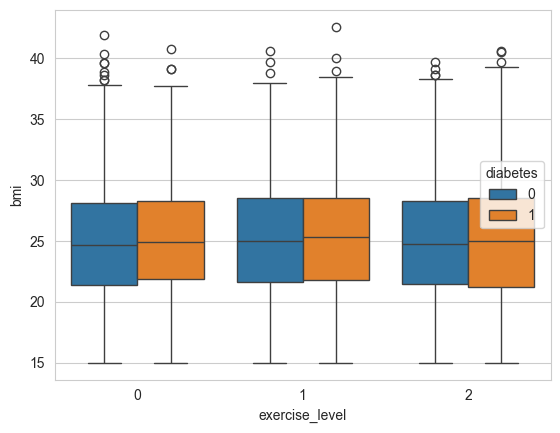

In [43]:
sns.boxplot(x='exercise_level', y='bmi', hue='diabetes', data=df)

In [44]:
df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)

diabetes             1.000000
heart_disease        0.857576
age                  0.822413
stroke               0.785239
glucose              0.028910
alcohol              0.027317
bmi                  0.017799
blood_pressure       0.010722
fatigue              0.009621
cholesterol          0.002031
chest_pain          -0.000826
dizziness           -0.006260
exercise_level      -0.009843
gender              -0.009989
smoking             -0.022884
health_risk_score         NaN
Name: diabetes, dtype: float64

In [46]:
from sklearn.linear_model import LogisticRegression

X = df[['exercise_level', 'bmi', 'age']]
y = df['diabetes']

model = LogisticRegression()
model.fit(X, y)

print(model.coef_)

[[-0.21626764  0.04153059  1.12239623]]


In [47]:
for feature, coef in zip(X.columns, model.coef_[0]):
    print(feature, coef)

exercise_level -0.21626764209231214
bmi 0.04153058760854716
age 1.1223962311477145


In [53]:
df.groupby('smoking')[['cholesterol', 'blood_pressure', 'fatigue']].mean()


,cholesterol,blood_pressure,fatigue
smoking,,,
0,223.308286,134.704305,0.518684
1,225.885343,134.194247,0.511820


In [52]:
df.groupby('alcohol')[['cholesterol', 'blood_pressure', 'fatigue']].mean()

,cholesterol,blood_pressure,fatigue
alcohol,,,
0,224.079422,134.031288,0.519856
1,225.150379,134.857200,0.510570


In [54]:
pd.crosstab(df['smoking'],df['chest_pain'], normalize = 'index')

chest_pain,0,1
smoking,,
0,0.493907,0.506093
1,0.498030,0.501970


In [55]:
pd.crosstab(df['alcohol'],df['chest_pain'], normalize = 'index')

chest_pain,0,1
alcohol,,
0,0.506619,0.493381
1,0.485441,0.514559


<Axes: xlabel='smoking', ylabel='cholesterol'>

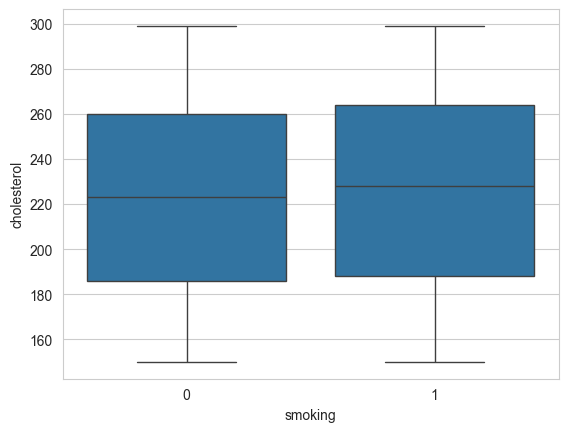

In [56]:
sns.boxplot(x= 'smoking', y = 'cholesterol',data = df)

<Axes: xlabel='smoking', ylabel='blood_pressure'>

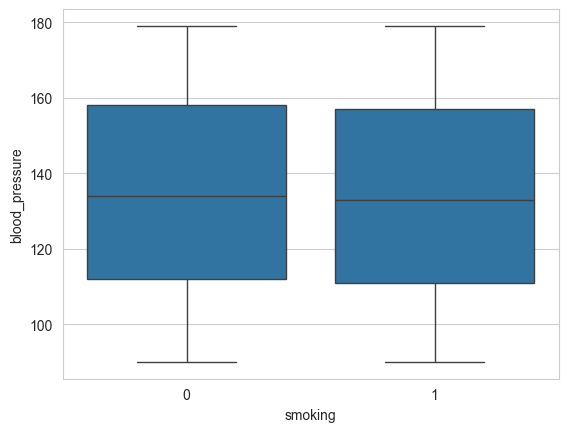

In [57]:
sns.boxplot(x = 'smoking', y = 'blood_pressure', data = df)

<Axes: xlabel='alcohol', ylabel='cholesterol'>

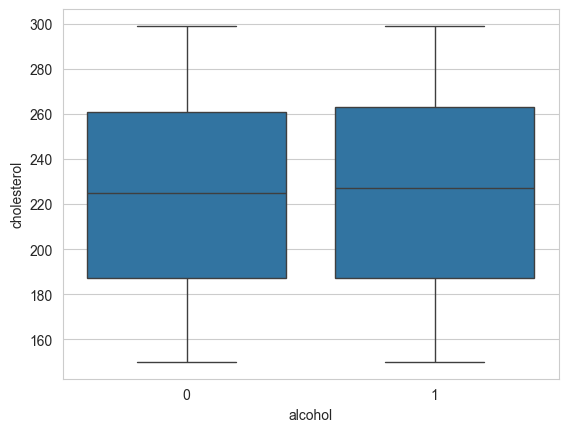

In [60]:
sns.boxplot(x='alcohol', y='cholesterol', data=df)


<Axes: xlabel='alcohol', ylabel='blood_pressure'>

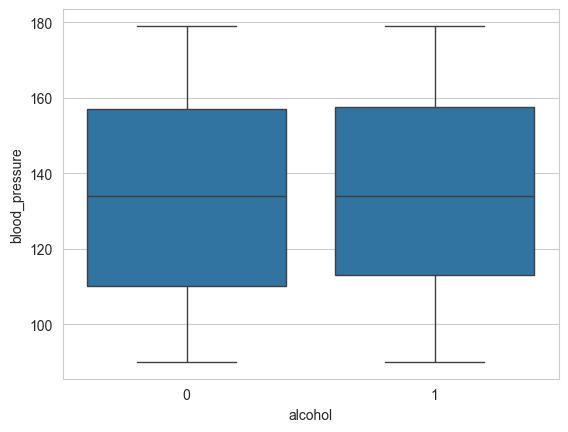

In [61]:
sns.boxplot(x='alcohol', y='blood_pressure', data=df)

In [22]:
X = df.drop(columns = ['heart_disease', 'diabetes', 'stroke','health_risk_score'])

In [23]:
y = df['diabetes']

In [24]:
from sklearn. model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)

print(f"Score is: {score}")

Score is: 0.989


In [28]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       646
           1       0.99      0.98      0.98       354

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [29]:
train_acc = model.score(X_train_scaled, y_train)
print("Training score is: ", train_acc)

Training score is:  0.98975


In [30]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(model,X_train_scaled, y_train, cv = 5, scoring = 'accuracy')
print(cv_score)
print("Mean CV score :", cv_score.mean())

[0.99    0.98875 0.98625 0.99625 0.98125]
Mean CV score : 0.9884999999999999


In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.987 0.989 0.982 0.987 0.997]
Mean: 0.9884000000000001


## For Regression

In [73]:
df[['gender']].drop_duplicates()

,gender
0,1
1,0


In [107]:
features =  [
    'age', 'bmi','gender','exercise_level', 'smoking', 'alcohol',
    'blood_pressure', 'glucose', 'fatigue',
    'chest_pain', 'dizziness', 'heart_disease', 'diabetes',
    'stroke','cholesterol'
]

In [108]:
df['health_risk_score'] = (
    df['bmi'] * 0.3 +
    df['blood_pressure'] * 0.2 +
    df['cholesterol']*0.4
)

In [109]:
df['health_risk_score'].value_counts()

health_risk_score
103.34    6
132.80    5
108.37    5
100.90    5
127.15    4
         ..
147.35    1
114.59    1
93.96     1
116.33    1
103.57    1
Name: count, Length: 3906, dtype: int64

In [110]:
target = ['health_risk_score']

In [111]:
X = df[features]
y = df[target]

In [112]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state=42)

In [113]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression R²: {r2_lr}")

Linear Regression R²: 1.0


In [115]:
# See if cholesterol is accidentally in X
print(X_train.columns.tolist())
print('health_risk_score' in X_train.columns)  # should be False

['age', 'bmi', 'gender', 'exercise_level', 'smoking', 'alcohol', 'blood_pressure', 'glucose', 'fatigue', 'chest_pain', 'dizziness', 'heart_disease', 'diabetes', 'stroke', 'cholesterol']
False


In [116]:
print(y_train.describe())
print(y_train.value_counts())

       health_risk_score
count        4000.000000
mean          124.248288
std            18.303426
min            82.900000
25%           109.057500
50%           124.890000
75%           139.182500
max           162.920000
health_risk_score
132.80               5
103.34               5
108.37               5
117.79               4
137.71               4
                    ..
99.82                1
99.79                1
120.94               1
99.79                1
82.90                1
Name: count, Length: 3292, dtype: int64


In [117]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))  # should be << 1.0

-3.855207595004906e-05


In [119]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Correct way: put scaler and model in a pipeline
pipeline = make_pipeline(StandardScaler(), LinearRegression())
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print(scores)

[1. 1. 1. 1. 1.]


In [120]:
print(X.shape)

(5000, 15)
